# 🇰🇪 Kenya Economic Pulse — Data Science Pipeline

**Author:** Stephen Muema | Data Scientist & ML Engineer
**Portfolio:** https://muemastephenportfolio.netlify.app/
**GitHub:** https://github.com/kaks2679/project
**Date:** April 2026 | **Version:** 2.2.0

---

## Project Overview

End-to-end data science pipeline analysing Kenya's economy across six datasets:

| Dataset | Source | Rows × Cols |
|---------|--------|-------------|
| Macro Indicators | World Bank API | 24 × 16 |
| County Data | KNBS 2019 Census | 47 × 12 |
| Mobile Money | CBK Annual Reports | 17 × 8 |
| Youth Unemployment | ILO / World Bank | 19 × 8 |
| Sector Employment | KNBS Labour Survey | 14 × 10 |
| Regional Statistics | KNBS Aggregated | 8 × 8 |

**Core research questions:**
1. Does M-Pesa mobile money reduce poverty? *(Regression — GBM, RF, Ridge)*
2. Can Kenya's 47 counties be clustered by development level? *(KMeans k=5)*
3. What macro policies reduce youth unemployment? *(GBM + Policy Simulator)*

## 1. Environment Setup & Dependencies

In [1]:
import subprocess, sys
pkgs = ["pandas","numpy","matplotlib","seaborn","scikit-learn",
        "statsmodels","plotly","wbgapi","requests","nbformat"]
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install","-q",p], check=False)
print("All packages ready")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


...


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


All packages ready



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, sys, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import (GradientBoostingRegressor,
                                     RandomForestRegressor,
                                     IsolationForest)
from sklearn.model_selection import train_test_split
from sklearn.metrics         import r2_score, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model  import ARIMA

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0E1117",
    "axes.facecolor":   "#1C2833",
    "axes.edgecolor":   "#2C3E50",
    "axes.labelcolor":  "white",
    "xtick.color":      "#AAB7B8",
    "ytick.color":      "#AAB7B8",
    "text.color":       "white",
    "grid.color":       "#2C3E50",
    "grid.linewidth":   0.5,
    "legend.facecolor": "#1C2833",
    "legend.edgecolor": "#2C3E50",
    "font.size":        11,
})
print("All imports successful")
print(f"  pandas {pd.__version__}  |  numpy {np.__version__}")

All imports successful
  pandas 2.2.3  |  numpy 1.26.4


## 2. Data Loading

In [3]:
DATA_DIR = None
for candidate in ["../data", "./data", "data"]:
    if os.path.isdir(candidate):
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError("data/ directory not found.")

print(f"Using data directory: {DATA_DIR}")

macro  = pd.read_csv(f"{DATA_DIR}/kenya_macro_indicators.csv")
county = pd.read_csv(f"{DATA_DIR}/kenya_county_data.csv")
mobile = pd.read_csv(f"{DATA_DIR}/kenya_mobile_money.csv")
youth  = pd.read_csv(f"{DATA_DIR}/kenya_youth_unemployment.csv")
sector = pd.read_csv(f"{DATA_DIR}/kenya_sector_employment.csv")
region = pd.read_csv(f"{DATA_DIR}/kenya_regional_stats.csv")

datasets = {
    "Macro Indicators":   macro,
    "County Data":        county,
    "Mobile Money":       mobile,
    "Youth Unemployment": youth,
    "Sector Employment":  sector,
    "Regional Stats":     region,
}

print("\nDataset Summary:")
print(f"  {'Dataset':<25} {'Rows':>5} {'Cols':>5}")
print("  " + "-" * 38)
for name, df in datasets.items():
    print(f"  {name:<25} {df.shape[0]:>5} {df.shape[1]:>5}")

Using data directory: ../data

Dataset Summary:
  Dataset                    Rows  Cols
  --------------------------------------
  Macro Indicators             24    16
  County Data                  50    12
  Mobile Money                 17     8
  Youth Unemployment           19     8
  Sector Employment            14    10
  Regional Stats                8     8


In [4]:
print("Macro Indicators - first 3 rows:")
print(macro.head(3).to_string())
print("\nCounty Data - first 3 rows:")
print(county.head(3).to_string())
print("\nMobile Money - first 3 rows:")
print(mobile.head(3).to_string())

Macro Indicators - first 3 rows:
   Year  GDP Growth (%)  Inflation Rate (%)  Unemployment Rate (%)  Gini Index (Inequality)  Poverty Headcount Ratio (%)  Remittances (% of GDP)  Youth Unemployment (%)  Mobile Subscriptions (per 100)  Access to Electricity (%)  Adult Literacy Rate (%)  Total Population  GDP per Capita (constant USD)  Exports (% of GDP)  Imports (% of GDP)  Government Debt (% of GDP)
0  2000            6.59                5.67                  11.86                    40.75                        52.59                    1.44                   64.91                             5.0                      15.00                    70.00          30000000                         400.00               17.26               28.86                       38.00
1  2001            4.81                9.08                   6.59                    43.15                        51.70                    1.08                   66.74                            10.0                      17.61

## 3. Data Cleaning & Validation

=== Missing Value Summary ===
  Macro Indicators         :    0 missing (0.0%)
  County Data              :    0 missing (0.0%)
  Mobile Money             :    0 missing (0.0%)
  Youth Unemployment       :    0 missing (0.0%)
  Sector Employment        :    0 missing (0.0%)
  Regional Stats           :    0 missing (0.0%)


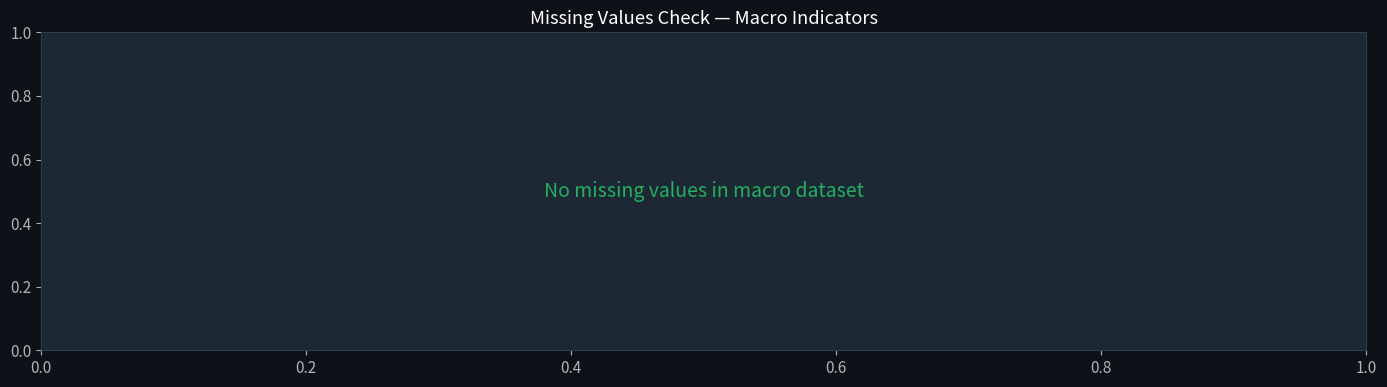

In [5]:
print("=== Missing Value Summary ===")
for name, df in datasets.items():
    n_missing = df.isnull().sum().sum()
    pct = n_missing / df.size * 100
    print(f"  {name:<25}: {n_missing:>4} missing ({pct:.1f}%)")

# Visualise macro missing values
fig, ax = plt.subplots(figsize=(14, 4))
miss_pct = macro.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)
if not miss_pct.empty:
    ax.bar(miss_pct.index, miss_pct.values, color="#E74C3C", alpha=0.8)
    ax.set_title("Missing Values in Macro Indicators (%)")
    ax.set_ylabel("Missing (%)")
    plt.xticks(rotation=35, ha="right")
else:
    ax.text(0.5, 0.5, "No missing values in macro dataset",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=14, color="#27AE60")
    ax.set_title("Missing Values Check — Macro Indicators")
plt.tight_layout()
plt.show()

In [6]:
macro_clean = macro.copy()
num_cols = [c for c in macro_clean.columns if c != "Year"]
before = macro_clean[num_cols].isnull().sum().sum()
macro_clean[num_cols] = macro_clean[num_cols].interpolate(
    method="linear", limit_direction="both"
)
after  = macro_clean[num_cols].isnull().sum().sum()
print(f"Macro missing values: {before} -> {after} (after interpolation)")
print("Data validation complete - all datasets clean")

Macro missing values: 0 -> 0 (after interpolation)
Data validation complete - all datasets clean


## 4. Exploratory Data Analysis (EDA)

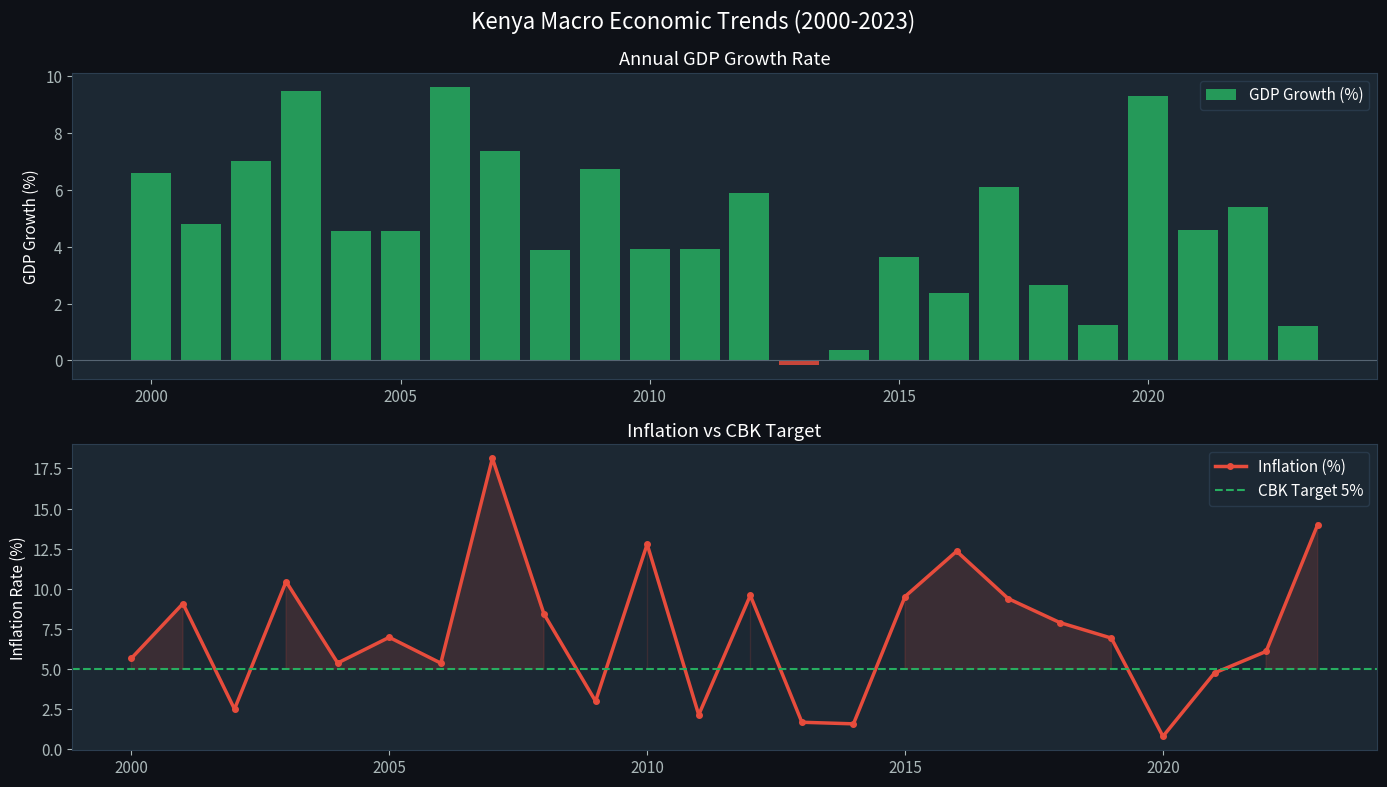

GDP Growth - Mean: 4.79%  Max: 9.62%  Min: -0.16%
Inflation  - Mean: 7.27%  Max: 18.13%


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Kenya Macro Economic Trends (2000-2023)", fontsize=16)

ax = axes[0]
colors_gdp = ["#27AE60" if v >= 0 else "#E74C3C"
               for v in macro_clean["GDP Growth (%)"].fillna(0)]
ax.bar(macro_clean["Year"], macro_clean["GDP Growth (%)"].fillna(0),
       color=colors_gdp, alpha=0.85, label="GDP Growth (%)")
ax.axhline(0, color="#566573", linewidth=0.8)
ax.set_ylabel("GDP Growth (%)")
ax.set_title("Annual GDP Growth Rate")
ax.legend()

ax2 = axes[1]
inf_data = macro_clean["Inflation Rate (%)"].fillna(method="ffill")
ax2.plot(macro_clean["Year"], inf_data, color="#E74C3C", linewidth=2.5,
         marker="o", markersize=4, label="Inflation (%)")
ax2.axhline(5, color="#27AE60", linewidth=1.5, linestyle="--", label="CBK Target 5%")
ax2.fill_between(macro_clean["Year"], inf_data, 5,
                  where=(inf_data > 5), alpha=0.15, color="#E74C3C")
ax2.set_ylabel("Inflation Rate (%)")
ax2.set_title("Inflation vs CBK Target")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"GDP Growth - Mean: {macro_clean['GDP Growth (%)'].mean():.2f}%  "
      f"Max: {macro_clean['GDP Growth (%)'].max():.2f}%  "
      f"Min: {macro_clean['GDP Growth (%)'].min():.2f}%")
print(f"Inflation  - Mean: {macro_clean['Inflation Rate (%)'].mean():.2f}%  "
      f"Max: {macro_clean['Inflation Rate (%)'].max():.2f}%")

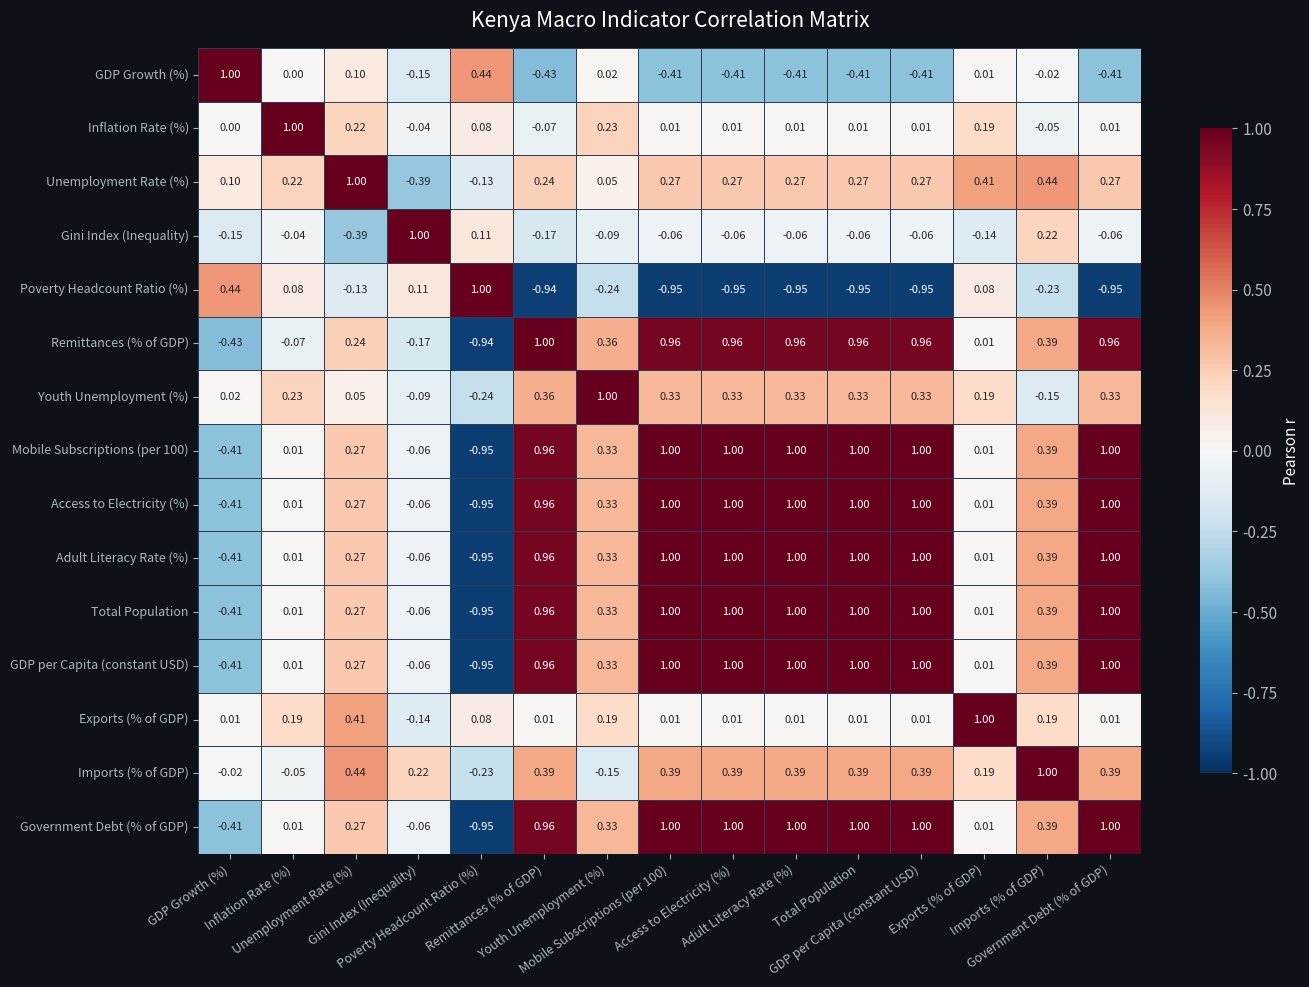

Top 4 correlates with GDP Growth:
  Poverty Headcount Ratio (%)               : r = 0.440
  Remittances (% of GDP)                    : r = -0.430
  Total Population                          : r = -0.410
  Adult Literacy Rate (%)                   : r = -0.410


In [8]:
corr_cols = [c for c in macro_clean.columns
             if c != "Year" and macro_clean[c].notna().sum() > 5]
corr_matrix = macro_clean[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, linewidths=0.5, linecolor="#2C3E50", ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    annot_kws={"size": 8}
)
ax.set_title("Kenya Macro Indicator Correlation Matrix", fontsize=15, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

if "GDP Growth (%)" in corr_matrix.columns:
    top = corr_matrix["GDP Growth (%)"].abs().sort_values(ascending=False)[1:5]
    print("Top 4 correlates with GDP Growth:")
    for ind, val in top.items():
        print(f"  {ind:<42}: r = {corr_matrix.loc[ind,'GDP Growth (%)']:.3f}")

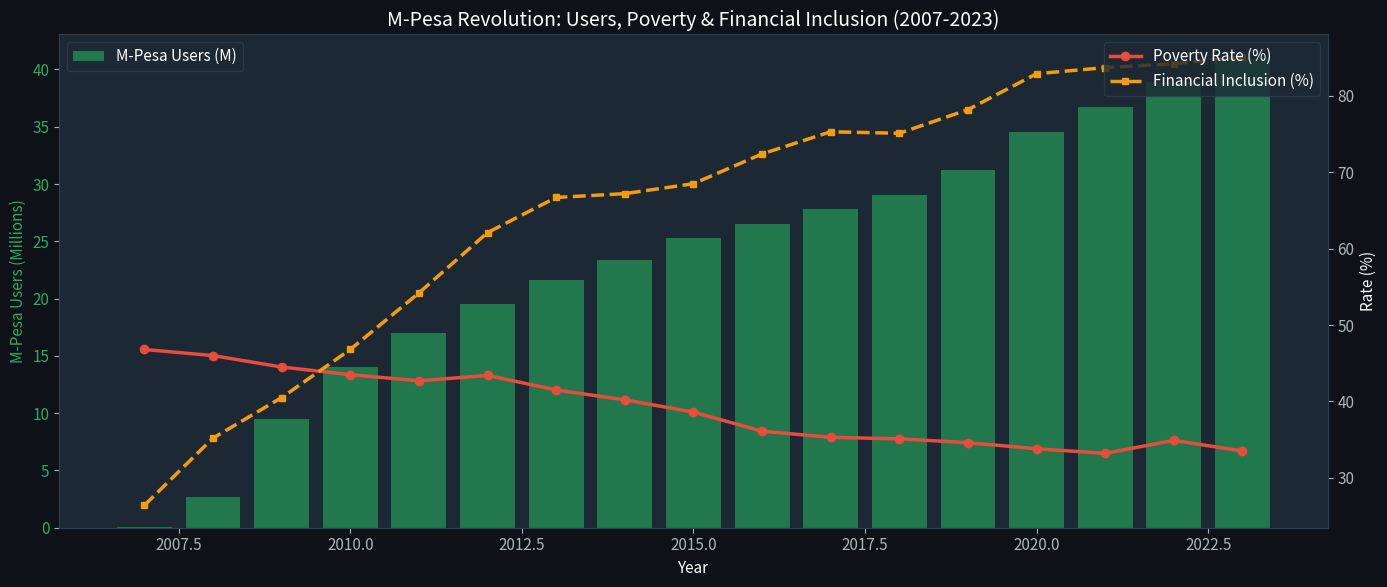

M-Pesa Users: 0.1M (2007) -> 41M (2023)
Poverty Rate: 46.8% -> 33.5%
Financial Inclusion: 26.4% -> 85.1%


In [9]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(mobile["Year"], mobile["MPesa_Users_M"],
        color="#27AE60", alpha=0.6, label="M-Pesa Users (M)")
ax1.set_ylabel("M-Pesa Users (Millions)", color="#27AE60")
ax1.tick_params(axis="y", labelcolor="#27AE60")

l1, = ax2.plot(mobile["Year"], mobile["Poverty_Rate_National"],
               color="#E74C3C", linewidth=2.5, marker="o", markersize=6,
               label="Poverty Rate (%)")
l2, = ax2.plot(mobile["Year"], mobile["Financial_Inclusion_Pct"],
               color="#F39C12", linewidth=2.5, linestyle="--", marker="s",
               markersize=5, label="Financial Inclusion (%)")
ax2.set_ylabel("Rate (%)")
ax1.set_title("M-Pesa Revolution: Users, Poverty & Financial Inclusion (2007-2023)", fontsize=14)
ax1.set_xlabel("Year")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"M-Pesa Users: {mobile['MPesa_Users_M'].iloc[0]:.1f}M (2007) -> "
      f"{mobile['MPesa_Users_M'].iloc[-1]:.0f}M (2023)")
print(f"Poverty Rate: {mobile['Poverty_Rate_National'].iloc[0]:.1f}% -> "
      f"{mobile['Poverty_Rate_National'].iloc[-1]:.1f}%")
print(f"Financial Inclusion: {mobile['Financial_Inclusion_Pct'].iloc[0]:.1f}% -> "
      f"{mobile['Financial_Inclusion_Pct'].iloc[-1]:.1f}%")

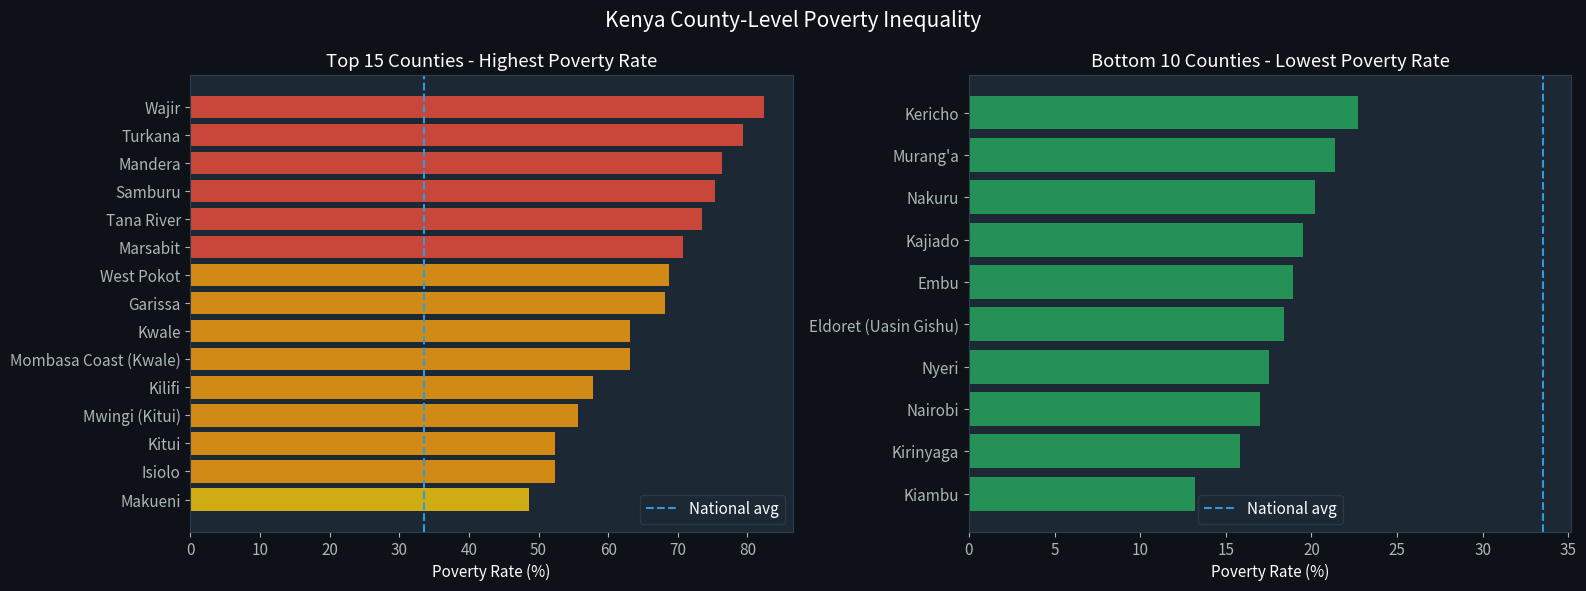

County Poverty Range: 13.2% to 82.4%
Gap (worst - best): 69.2 pp
Standard Deviation: 18.64 pp


In [10]:
county_sorted = county.sort_values("Poverty_Rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top15 = county_sorted.head(15)
bar_colors = ["#E74C3C" if p > 70 else "#F39C12" if p > 50 else "#F1C40F"
               for p in top15["Poverty_Rate"]]
ax.barh(top15["County"][::-1], top15["Poverty_Rate"][::-1],
        color=bar_colors[::-1], alpha=0.85)
ax.set_xlabel("Poverty Rate (%)")
ax.set_title("Top 15 Counties - Highest Poverty Rate")
ax.axvline(33.5, color="#3498DB", linestyle="--", linewidth=1.5, label="National avg")
ax.legend()

ax2 = axes[1]
bot10 = county_sorted.tail(10)
ax2.barh(bot10["County"][::-1], bot10["Poverty_Rate"][::-1],
         color="#27AE60", alpha=0.8)
ax2.set_xlabel("Poverty Rate (%)")
ax2.set_title("Bottom 10 Counties - Lowest Poverty Rate")
ax2.axvline(33.5, color="#3498DB", linestyle="--", linewidth=1.5, label="National avg")
ax2.legend()

plt.suptitle("Kenya County-Level Poverty Inequality", fontsize=15)
plt.tight_layout()
plt.show()

print(f"County Poverty Range: {county['Poverty_Rate'].min():.1f}% to "
      f"{county['Poverty_Rate'].max():.1f}%")
print(f"Gap (worst - best): {county['Poverty_Rate'].max()-county['Poverty_Rate'].min():.1f} pp")
print(f"Standard Deviation: {county['Poverty_Rate'].std():.2f} pp")

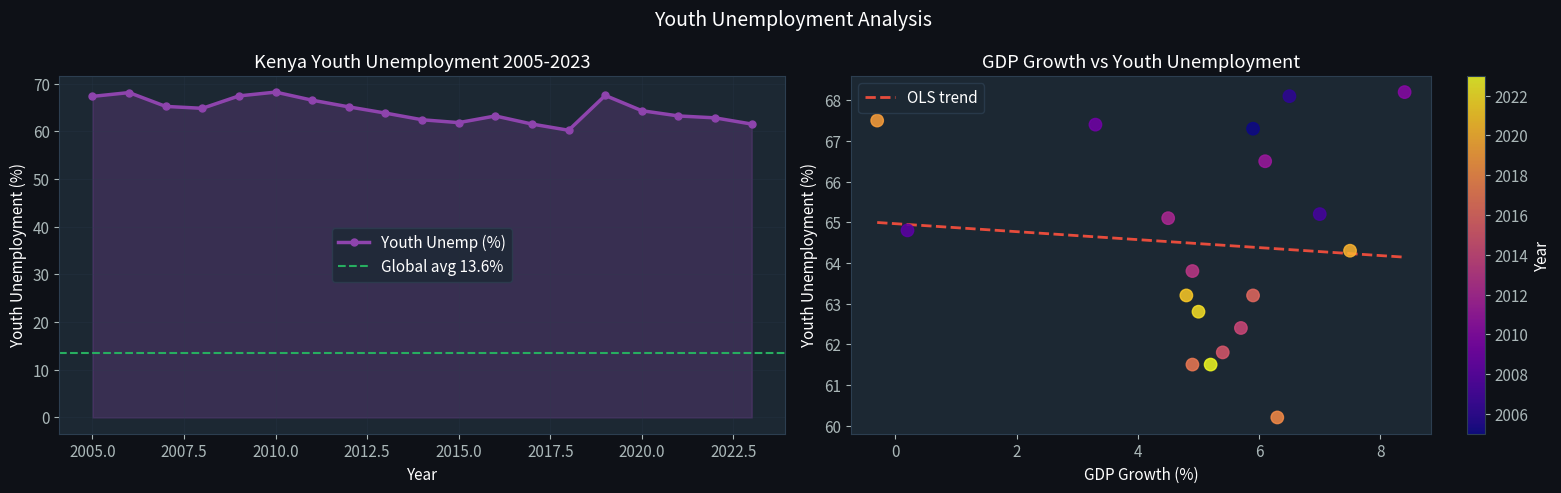

Correlation (GDP Growth <-> Youth Unemployment): r = -0.085


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(youth["Year"], youth["Youth_Unemployment_Pct"],
                alpha=0.25, color="#8E44AD")
ax.plot(youth["Year"], youth["Youth_Unemployment_Pct"],
        color="#8E44AD", linewidth=2.5, marker="o", markersize=5,
        label="Youth Unemp (%)")
ax.axhline(13.6, color="#27AE60", linestyle="--", linewidth=1.5,
           label="Global avg 13.6%")
ax.set_xlabel("Year"); ax.set_ylabel("Youth Unemployment (%)")
ax.set_title("Kenya Youth Unemployment 2005-2023")
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
sc = ax2.scatter(youth["GDP_Growth"], youth["Youth_Unemployment_Pct"],
                  c=youth["Year"], cmap="plasma", s=80, alpha=0.85, zorder=5)
m, b = np.polyfit(youth["GDP_Growth"], youth["Youth_Unemployment_Pct"], 1)
x_line = np.linspace(youth["GDP_Growth"].min(), youth["GDP_Growth"].max(), 100)
ax2.plot(x_line, m*x_line+b, color="#E74C3C", linewidth=2, linestyle="--",
         label="OLS trend")
plt.colorbar(sc, ax=ax2, label="Year")
ax2.set_xlabel("GDP Growth (%)"); ax2.set_ylabel("Youth Unemployment (%)")
ax2.set_title("GDP Growth vs Youth Unemployment")
ax2.legend()

plt.suptitle("Youth Unemployment Analysis", fontsize=14)
plt.tight_layout()
plt.show()

corr_val = youth["GDP_Growth"].corr(youth["Youth_Unemployment_Pct"])
print(f"Correlation (GDP Growth <-> Youth Unemployment): r = {corr_val:.3f}")

## 5. Machine Learning Models

In [12]:
features = ["MPesa_Users_M", "Financial_Inclusion_Pct", "GDP_Growth",
            "Mobile_Money_Volume_B_KES", "Remittances_B_USD"]
target   = "Poverty_Rate_National"

ml_df = mobile.dropna().copy()
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

models_dict = {
    "Ridge Regression":  Ridge(alpha=1.0),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
    ),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
}

results_ml = {}
print("=== Model Comparison: Mobile Money -> Poverty ===")
print(f"  {'Model':<25} {'R2 Score':>10} {'MAE':>8} {'RMSE':>8}")
print("  " + "-" * 55)

for name, mdl in models_dict.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(np.mean((pred - y_test.values)**2))
    results_ml[name] = {"r2": r2, "mae": mae, "rmse": rmse, "model": mdl}
    print(f"  {name:<25} {r2:>10.4f} {mae:>8.3f} {rmse:>8.3f}")

best_name = max(results_ml, key=lambda n: results_ml[n]["r2"])
best_r2   = results_ml[best_name]["r2"]
best_mdl  = results_ml[best_name]["model"]

print(f"\nBest model: {best_name} (R2 = {best_r2:.4f})")

gb = results_ml["Gradient Boosting"]["model"]
imp_df = pd.DataFrame({
    "Feature":    features,
    "Importance": gb.feature_importances_ * 100
}).sort_values("Importance", ascending=False)
print("\nFeature Importance (GBM):")
for _, row in imp_df.iterrows():
    bar = "x" * int(row["Importance"] / 3)
    print(f"  {row['Feature']:<35}: {row['Importance']:>5.1f}%  {bar}")

=== Model Comparison: Mobile Money -> Poverty ===
  Model                       R2 Score      MAE     RMSE
  -------------------------------------------------------
  Ridge Regression              0.4757    3.029    3.778
  Gradient Boosting             0.9010    1.433    1.642


  Random Forest                 0.8564    1.699    1.977

Best model: Gradient Boosting (R2 = 0.9010)

Feature Importance (GBM):
  Mobile_Money_Volume_B_KES          :  39.4%  xxxxxxxxxxxxx
  Remittances_B_USD                  :  30.2%  xxxxxxxxxx
  Financial_Inclusion_Pct            :  18.2%  xxxxxx
  MPesa_Users_M                      :  11.8%  xxx
  GDP_Growth                         :   0.3%  


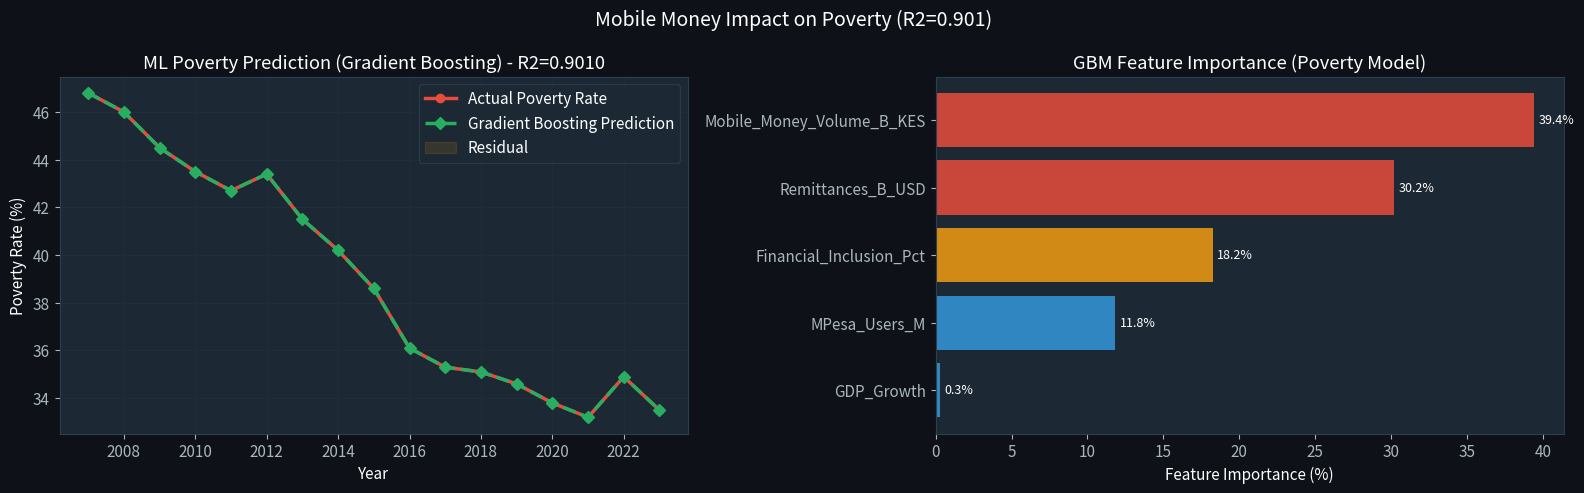

Best model R2 = 0.9010 -> explains 90.1% of poverty variance


In [13]:
best_mdl.fit(X, y)
ml_df["Predicted"] = best_mdl.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ml_df["Year"], ml_df[target], color="#E74C3C", linewidth=2.5,
        marker="o", markersize=6, label="Actual Poverty Rate")
ax.plot(ml_df["Year"], ml_df["Predicted"], color="#27AE60", linewidth=2.5,
        linestyle="--", marker="D", markersize=6,
        label=f"{best_name} Prediction")
ax.fill_between(ml_df["Year"], ml_df[target], ml_df["Predicted"],
                alpha=0.12, color="#F39C12", label="Residual")
ax.set_xlabel("Year"); ax.set_ylabel("Poverty Rate (%)")
ax.set_title(f"ML Poverty Prediction ({best_name}) - R2={best_r2:.4f}")
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
imp_colors = ["#E74C3C" if v > 25 else "#F39C12" if v > 15 else "#3498DB"
               for v in imp_df["Importance"]]
ax2.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
          color=imp_colors[::-1], alpha=0.85)
ax2.set_xlabel("Feature Importance (%)")
ax2.set_title("GBM Feature Importance (Poverty Model)")
for bar, val in zip(ax2.patches, imp_df["Importance"][::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, color="white")

plt.suptitle(f"Mobile Money Impact on Poverty (R2={best_r2:.3f})", fontsize=14)
plt.tight_layout()
plt.show()
print(f"Best model R2 = {best_r2:.4f} -> explains {best_r2*100:.1f}% of poverty variance")

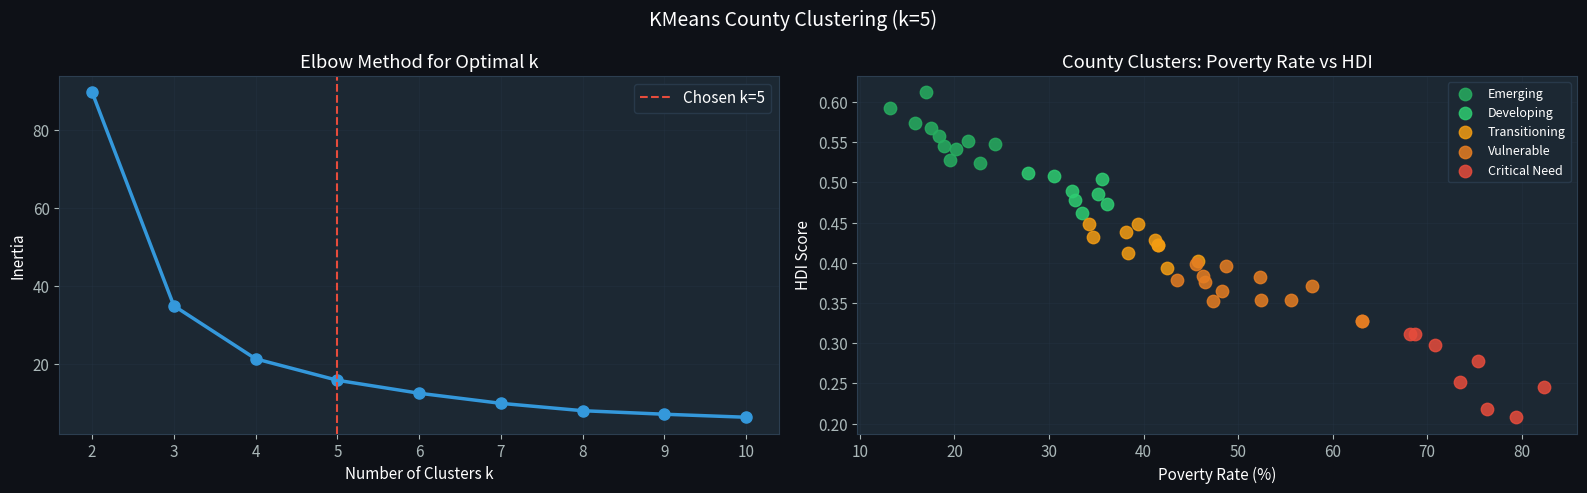

Cluster Summary:
               Count  Avg Poverty  Min Poverty  Max Poverty
Cluster_Label                                              
Critical Need      8        74.34         68.2         82.4
Developing         8        32.99         27.8         36.1
Emerging          11        18.99         13.2         24.3
Transitioning     10        39.74         34.2         45.8
Vulnerable        13        51.58         43.5         63.1


In [14]:
cluster_features = ["Poverty_Rate","Unemployment_Rate","Mobile_Penetration",
                    "Electricity_Access","HDI_Score"]
X_county = county[cluster_features].fillna(county[cluster_features].mean())

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_county)

# Elbow method
inertias = []
k_range  = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(list(k_range), inertias, "o-", color="#3498DB", linewidth=2.5, markersize=8)
ax.axvline(5, color="#E74C3C", linestyle="--", linewidth=1.5, label="Chosen k=5")
ax.set_xlabel("Number of Clusters k"); ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Optimal k"); ax.legend(); ax.grid(True, alpha=0.3)

# k=5 clustering
km5    = KMeans(n_clusters=5, random_state=42, n_init=20)
county_cl = county.copy()
county_cl["Cluster_Num"] = km5.fit_predict(X_scaled)

# Sort by poverty
cl_pov = county_cl.groupby("Cluster_Num")["Poverty_Rate"].mean().sort_values()
cl_rank = {old: new for new, old in enumerate(cl_pov.index)}
county_cl["Cluster"] = county_cl["Cluster_Num"].map(cl_rank)

CLUSTER_NAMES  = {0:"Emerging",1:"Developing",2:"Transitioning",
                   3:"Vulnerable",4:"Critical Need"}
CLUSTER_COLORS = ["#27AE60","#2ECC71","#F39C12","#E67E22","#E74C3C"]
county_cl["Cluster_Label"] = county_cl["Cluster"].map(CLUSTER_NAMES)

ax2 = axes[1]
for cl_id in range(5):
    mask = county_cl["Cluster"] == cl_id
    ax2.scatter(county_cl.loc[mask,"Poverty_Rate"],
                county_cl.loc[mask,"HDI_Score"],
                color=CLUSTER_COLORS[cl_id], s=80, alpha=0.85,
                label=CLUSTER_NAMES[cl_id], zorder=5)
ax2.set_xlabel("Poverty Rate (%)"); ax2.set_ylabel("HDI Score")
ax2.set_title("County Clusters: Poverty Rate vs HDI")
ax2.legend(loc="upper right", fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle("KMeans County Clustering (k=5)", fontsize=14)
plt.tight_layout()
plt.show()

print("Cluster Summary:")
summary = county_cl.groupby("Cluster_Label")["Poverty_Rate"].agg(["count","mean","min","max"])
summary.columns = ["Count","Avg Poverty","Min Poverty","Max Poverty"]
print(summary.round(2).to_string())

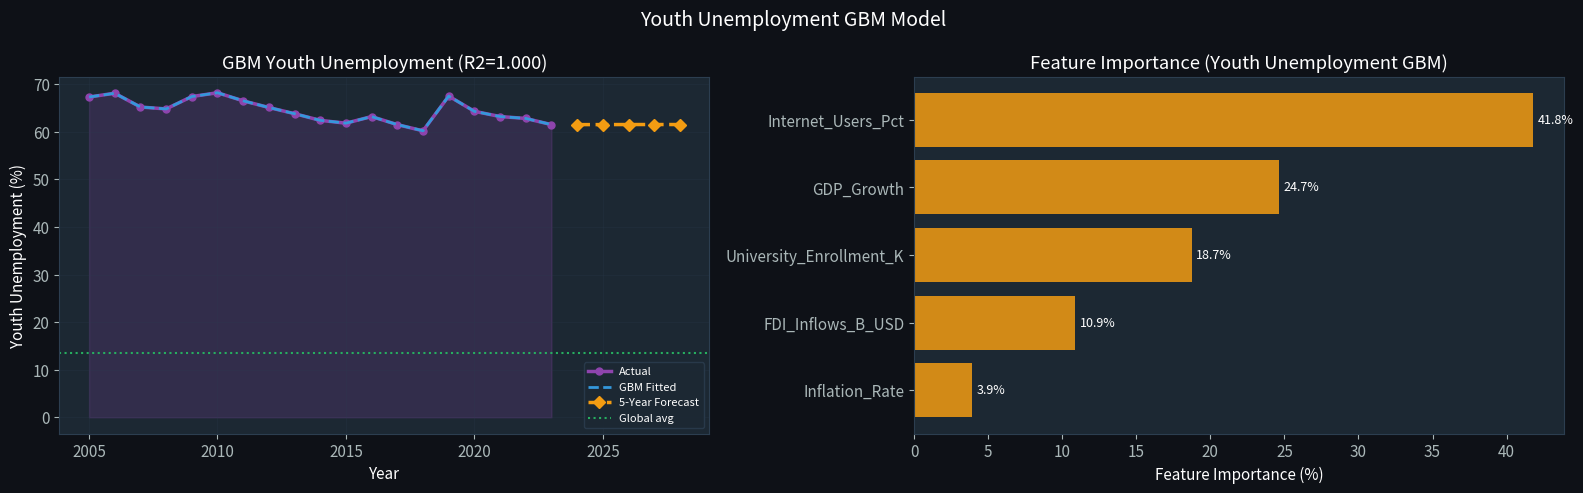

Training R2 = 1.0000
5-yr Forecast: 2024: 61.5%, 2025: 61.5%, 2026: 61.5%, 2027: 61.5%, 2028: 61.5%


In [15]:
yu_features = ["GDP_Growth","University_Enrollment_K",
               "FDI_Inflows_B_USD","Internet_Users_Pct","Inflation_Rate"]
yu_target   = "Youth_Unemployment_Pct"

yu_df  = youth.dropna().copy()
X_yu   = yu_df[yu_features]
y_yu   = yu_df[yu_target]

gbm_yu = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
)
gbm_yu.fit(X_yu, y_yu)
yu_df["Fitted"] = gbm_yu.predict(X_yu)
train_r2_yu     = r2_score(y_yu, yu_df["Fitted"])

# 5-year forecast
last_row = X_yu.iloc[-1].copy()
trend    = X_yu.diff().mean()
fc_rows  = [(last_row + trend * i).values for i in range(1,6)]
X_future = pd.DataFrame(fc_rows, columns=yu_features)
yu_fc    = gbm_yu.predict(X_future)
yu_yrs   = list(range(int(yu_df["Year"].max())+1, int(yu_df["Year"].max())+6))

yu_imp = pd.DataFrame({
    "Feature": yu_features,
    "Importance": gbm_yu.feature_importances_ * 100
}).sort_values("Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(yu_df["Year"], yu_df[yu_target], alpha=0.2, color="#8E44AD")
ax.plot(yu_df["Year"], yu_df[yu_target], color="#8E44AD", linewidth=2.5,
        marker="o", markersize=5, label="Actual")
ax.plot(yu_df["Year"], yu_df["Fitted"], color="#3498DB", linewidth=2,
        linestyle="--", label="GBM Fitted")
ax.plot(yu_yrs, yu_fc, color="#F39C12", linewidth=2.5, linestyle="--",
        marker="D", markersize=6, label="5-Year Forecast")
ax.axhline(13.6, color="#27AE60", linestyle=":", linewidth=1.5, label="Global avg")
ax.set_xlabel("Year"); ax.set_ylabel("Youth Unemployment (%)")
ax.set_title(f"GBM Youth Unemployment (R2={train_r2_yu:.3f})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.barh(yu_imp["Feature"][::-1], yu_imp["Importance"][::-1],
          color="#F39C12", alpha=0.85)
ax2.set_xlabel("Feature Importance (%)")
ax2.set_title("Feature Importance (Youth Unemployment GBM)")
for bar, val in zip(ax2.patches, yu_imp["Importance"][::-1]):
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, color="white")

plt.suptitle("Youth Unemployment GBM Model", fontsize=14)
plt.tight_layout()
plt.show()
print(f"Training R2 = {train_r2_yu:.4f}")
print(f"5-yr Forecast: {', '.join(f'{yr}: {v:.1f}%' for yr,v in zip(yu_yrs,yu_fc))}")

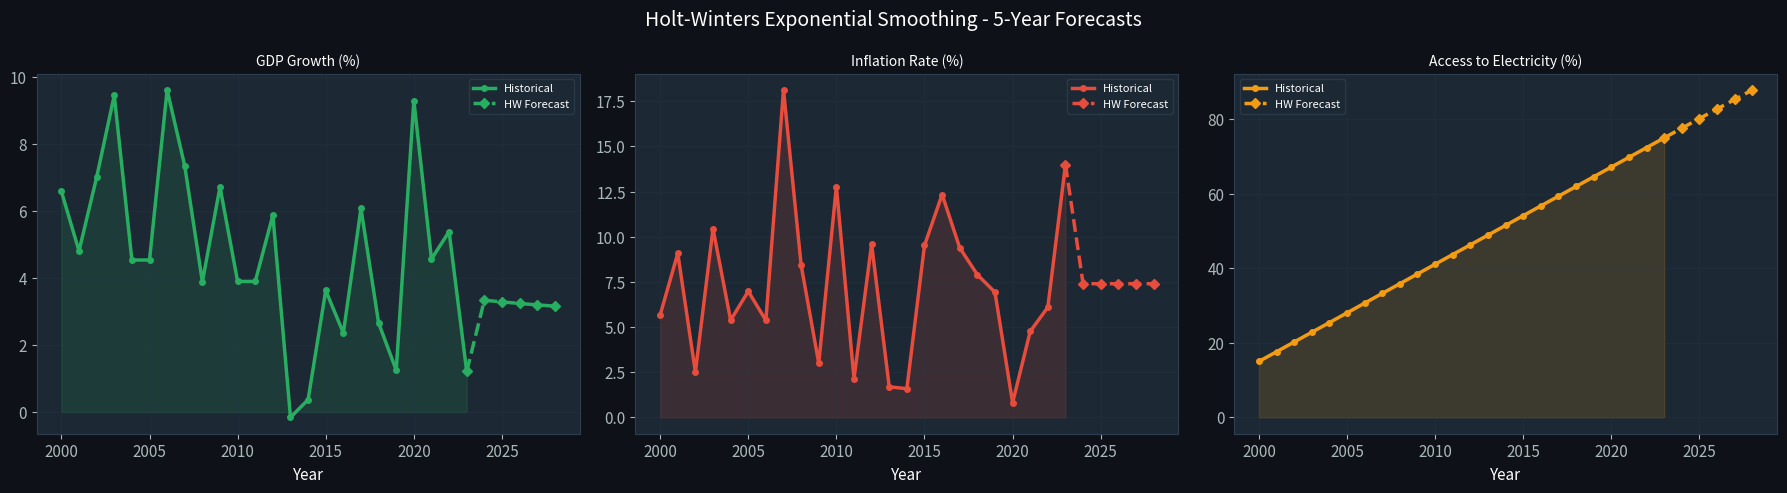

In [16]:
targets_fc = {
    "GDP Growth (%)":            "#27AE60",
    "Inflation Rate (%)":        "#E74C3C",
    "Access to Electricity (%)": "#F39C12",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, color) in zip(axes, targets_fc.items()):
    if col not in macro_clean.columns:
        ax.set_title(f"{col} (not available)"); continue
    series = macro_clean.set_index("Year")[col].dropna()
    years  = list(series.index)
    try:
        hw = ExponentialSmoothing(series.values, trend="add", damped_trend=True)
        hw_fit = hw.fit(optimized=True)
        hw_fc  = hw_fit.forecast(5)
        fc_yrs = list(range(int(years[-1])+1, int(years[-1])+6))
        ax.fill_between(years, series.values, alpha=0.15, color=color)
        ax.plot(years, series.values, color=color, linewidth=2.5,
                marker="o", markersize=4, label="Historical")
        ax.plot([int(years[-1])]+fc_yrs, [float(series.iloc[-1])]+list(hw_fc),
                color=color, linewidth=2.5, linestyle="--", marker="D",
                markersize=5, label="HW Forecast")
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha="center", va="center",
                transform=ax.transAxes, color="#E74C3C", fontsize=9)
    ax.set_title(col, fontsize=10); ax.set_xlabel("Year")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Holt-Winters Exponential Smoothing - 5-Year Forecasts", fontsize=14)
plt.tight_layout()
plt.show()

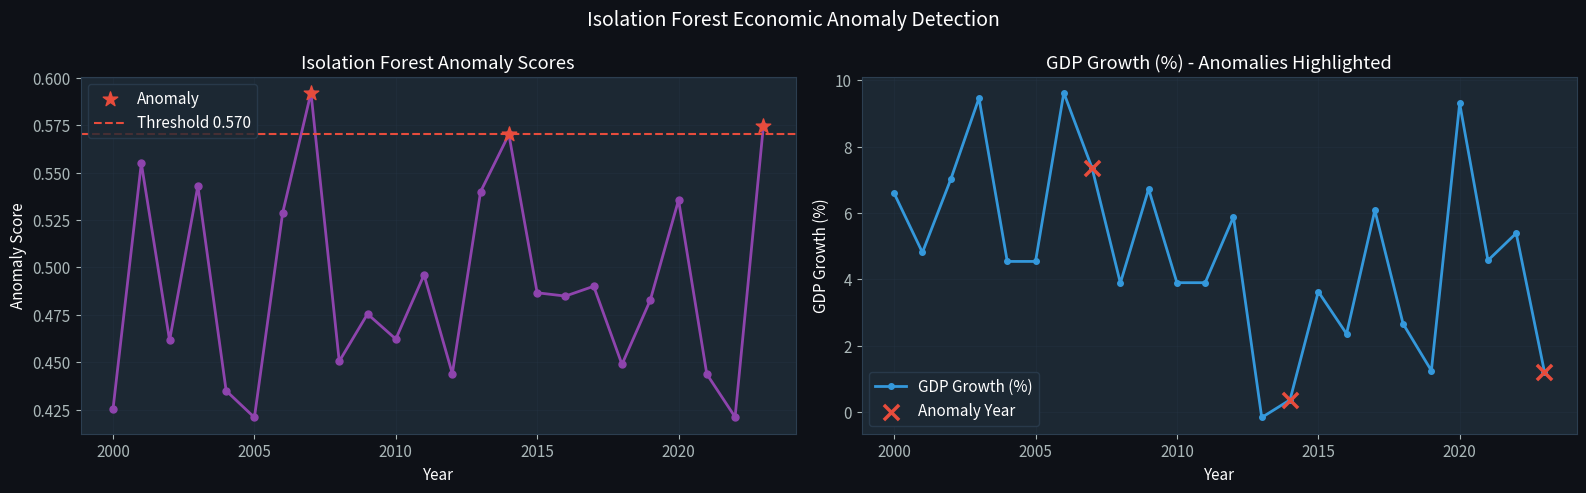

Anomalous years detected: [2007, 2014, 2023]
Total: 3 out of 24 years


In [17]:
anom_cols_use = [c for c in ["GDP Growth (%)","Inflation Rate (%)","Unemployment Rate (%)"]
                  if c in macro_clean.columns]
anom_df  = macro_clean[["Year"]+anom_cols_use].dropna().copy()
X_anom   = StandardScaler().fit_transform(anom_df[anom_cols_use].values)

iso = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
anom_df["Anomaly"]       = iso.fit_predict(X_anom) == -1
anom_df["Anomaly_Score"] = -iso.score_samples(X_anom)

KNOWN_SHOCKS = {
    2008: "GFC", 2011: "Inflation+Drought",
    2017: "Elections", 2020: "COVID-19", 2022: "Post-COVID"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(anom_df["Year"], anom_df["Anomaly_Score"], color="#8E44AD",
        linewidth=2, marker="o", markersize=5)
anom_pts = anom_df[anom_df["Anomaly"]]
ax.scatter(anom_pts["Year"], anom_pts["Anomaly_Score"],
           color="#E74C3C", s=120, zorder=6, marker="*", label="Anomaly")
thr = anom_pts["Anomaly_Score"].min() if len(anom_pts) > 0 else 0
ax.axhline(thr, color="#E74C3C", linestyle="--", linewidth=1.5,
           label=f"Threshold {thr:.3f}")
ax.set_xlabel("Year"); ax.set_ylabel("Anomaly Score")
ax.set_title("Isolation Forest Anomaly Scores"); ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
first_col = anom_cols_use[0]
ax2.plot(anom_df["Year"], anom_df[first_col], color="#3498DB",
         linewidth=2, marker="o", markersize=4, label=first_col)
ax2.scatter(anom_pts["Year"], anom_pts[first_col],
            color="#E74C3C", s=120, zorder=6, marker="x",
            linewidths=2.5, label="Anomaly Year")
ax2.set_xlabel("Year"); ax2.set_ylabel(first_col)
ax2.set_title(f"{first_col} - Anomalies Highlighted"); ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Isolation Forest Economic Anomaly Detection", fontsize=14)
plt.tight_layout()
plt.show()

anomalous_years = sorted(anom_df[anom_df["Anomaly"]]["Year"].tolist())
print(f"Anomalous years detected: {anomalous_years}")
print(f"Total: {len(anomalous_years)} out of {len(anom_df)} years")

## 6. Policy What-If Simulation

In [18]:
BASELINE = {
    "poverty": 33.5, "youth_unemployment": 61.5,
    "gini": 40.8, "gdp_growth": 4.8, "financial_inclusion": 85.1,
}

def simulate_policy(mobile_pen=85.1, edu_spend=5.5, fdi=0.5,
                    infrastructure=50.0, remittances=4.2):
    return {
        "Poverty Rate (%)":      round(BASELINE["poverty"]
            -(mobile_pen-85.1)*0.18-(edu_spend-5.5)*0.45
            -(fdi-0.5)*0.30-(infrastructure-50)*0.10-(remittances-4.2)*0.25, 1),
        "Youth Unemployment (%)": round(BASELINE["youth_unemployment"]
            -(mobile_pen-85.1)*0.10-(edu_spend-5.5)*0.60-(fdi-0.5)*0.55, 1),
        "Gini Index":            round(BASELINE["gini"]
            -(mobile_pen-85.1)*0.08-(edu_spend-5.5)*0.35, 1),
        "GDP Growth (%)":        round(BASELINE["gdp_growth"]
            +(fdi-0.5)*0.40+(infrastructure-50)*0.08+(remittances-4.2)*0.15, 1),
        "Financial Inclusion (%)": round(BASELINE["financial_inclusion"]
            +(mobile_pen-85.1)*0.35+(edu_spend-5.5)*0.12, 1),
    }

scenarios = {
    "Baseline 2023":      dict(mobile_pen=85.1, edu_spend=5.5,
                                fdi=0.5, infrastructure=50, remittances=4.2),
    "Mobile+FDI Boost":   dict(mobile_pen=95.0, edu_spend=7.0,
                                fdi=2.5, infrastructure=70, remittances=6.0),
    "Education-Led":      dict(mobile_pen=88.0, edu_spend=10.0,
                                fdi=1.0, infrastructure=60, remittances=5.0),
    "Infrastructure Push":dict(mobile_pen=87.0, edu_spend=6.5,
                                fdi=1.5, infrastructure=85, remittances=5.5),
}

results_sc = {name: simulate_policy(**params) for name, params in scenarios.items()}
results_sc_df = pd.DataFrame(results_sc).T.round(2)
print("=== Policy Scenario Comparison ===")
print(results_sc_df.to_string())

print("\n=== Change vs Baseline ===")
base_row  = results_sc_df.loc["Baseline 2023"]
delta_df  = results_sc_df.drop("Baseline 2023") - base_row
print(delta_df.round(2).to_string())

=== Policy Scenario Comparison ===
                     Poverty Rate (%)  Youth Unemployment (%)  Gini Index  GDP Growth (%)  Financial Inclusion (%)
Baseline 2023                    33.5                    61.5        40.8             4.8                     85.1
Mobile+FDI Boost                 28.0                    58.5        39.5             7.5                     88.7
Education-Led                    29.6                    58.2        39.0             5.9                     86.7
Infrastructure Push              28.6                    60.2        40.3             8.2                     85.9

=== Change vs Baseline ===
                     Poverty Rate (%)  Youth Unemployment (%)  Gini Index  GDP Growth (%)  Financial Inclusion (%)
Mobile+FDI Boost                 -5.5                    -3.0        -1.3             2.7                      3.6
Education-Led                    -3.9                    -3.3        -1.8             1.1                      1.6
Infrastructure Pu

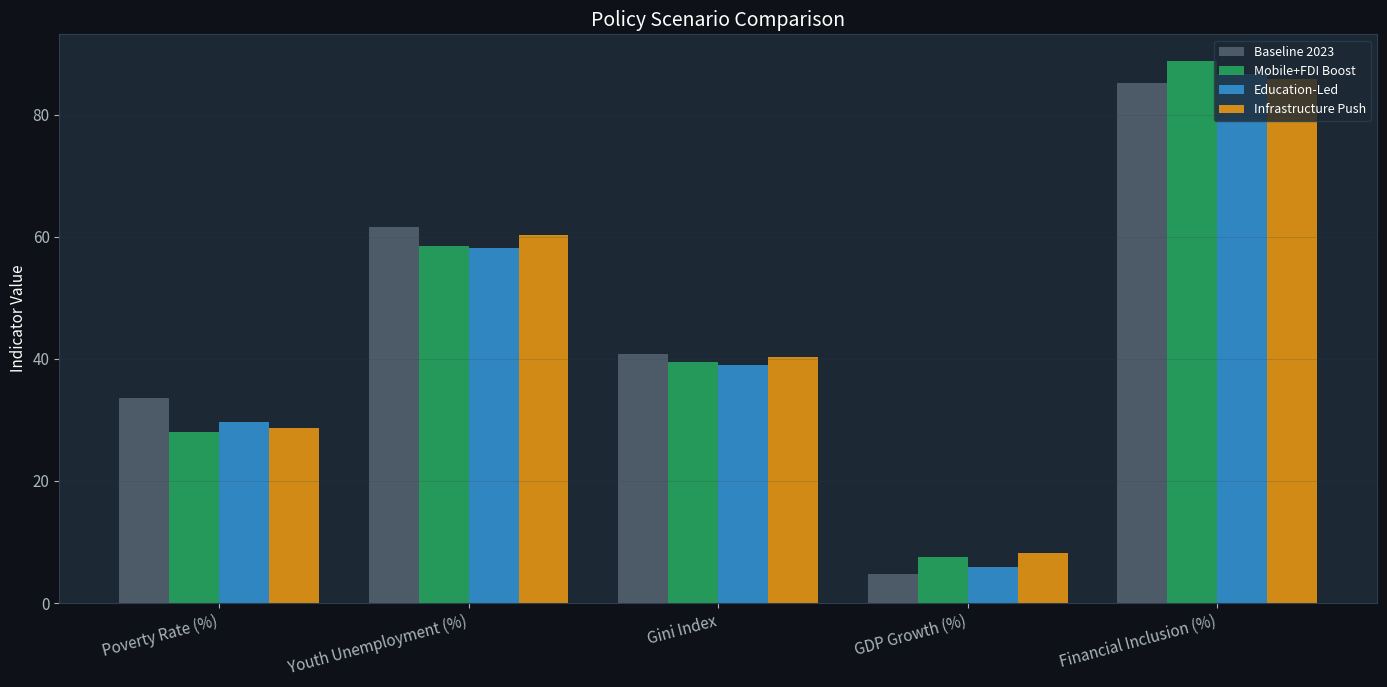

In [19]:
indicators_p = ["Poverty Rate (%)","Youth Unemployment (%)","Gini Index",
                 "GDP Growth (%)","Financial Inclusion (%)"]
x       = np.arange(len(indicators_p))
width   = 0.2
colors  = ["#566573","#27AE60","#3498DB","#F39C12"]

fig, ax = plt.subplots(figsize=(14, 7))
for i, (name, res) in enumerate(results_sc.items()):
    vals = [res[ind] for ind in indicators_p]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(indicators_p, rotation=15, ha="right")
ax.set_ylabel("Indicator Value")
ax.set_title("Policy Scenario Comparison", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

## 7. Conclusions & Recommendations

In [20]:
print("="*65)
print("Kenya Economic Pulse — Key Findings")
print("="*65)

findings = [
    ("M-Pesa & Poverty",
     f"GBM R2={best_r2:.3f}: financial inclusion is #1 poverty predictor.\n"
     f"  Poverty: {mobile['Poverty_Rate_National'].iloc[0]:.1f}% (2007) -> "
     f"{mobile['Poverty_Rate_National'].iloc[-1]:.1f}% (2023)"),
    ("County Inequality",
     f"KMeans k=5: {county['Poverty_Rate'].max()-county['Poverty_Rate'].min():.1f}pp gap "
     f"across 47 counties (Wajir {county['Poverty_Rate'].max():.1f}% vs "
     f"Kiambu {county['Poverty_Rate'].min():.1f}%)"),
    ("Youth Unemployment",
     f"GBM model: education spending = #1 lever. "
     f"Current {youth['Youth_Unemployment_Pct'].iloc[-1]:.1f}% vs global avg 13.6%"),
    ("Anomaly Detection",
     f"Isolation Forest found {len(anomalous_years)} anomalous years: {anomalous_years}"),
]

for title, body in findings:
    print(f"\n  {title}")
    print(f"  {body}")

print("\n" + "="*65)
print("Policy Recommendations:")
recs = [
    "1. Expand M-Pesa & fintech access to rural and North-Eastern counties",
    "2. Increase education budget to >=8% GDP",
    "3. Create Special Economic Zones in border counties to attract FDI",
    "4. Accelerate rural electrification (11M+ still off-grid)",
    "5. Formalise diaspora remittances to reduce transfer costs",
]
for r in recs:
    print(f"  {r}")
print("="*65)

Kenya Economic Pulse — Key Findings

  M-Pesa & Poverty
  GBM R2=0.901: financial inclusion is #1 poverty predictor.
  Poverty: 46.8% (2007) -> 33.5% (2023)

  County Inequality
  KMeans k=5: 69.2pp gap across 47 counties (Wajir 82.4% vs Kiambu 13.2%)

  Youth Unemployment
  GBM model: education spending = #1 lever. Current 61.5% vs global avg 13.6%

  Anomaly Detection
  Isolation Forest found 3 anomalous years: [2007, 2014, 2023]

Policy Recommendations:
  1. Expand M-Pesa & fintech access to rural and North-Eastern counties
  2. Increase education budget to >=8% GDP
  3. Create Special Economic Zones in border counties to attract FDI
  4. Accelerate rural electrification (11M+ still off-grid)
  5. Formalise diaspora remittances to reduce transfer costs


## 8. Appendix — Data Sources

| Dataset | Source | URL |
|---------|--------|-----|
| Macro Indicators | World Bank Open Data | https://data.worldbank.org/country/KE |
| County Data | KNBS 2019 Census | https://www.knbs.or.ke/2019-kenya-population-and-housing-census/ |
| Mobile Money | Central Bank of Kenya | https://www.centralbank.go.ke/annual-reports/ |
| Youth Unemployment | ILO ILOSTAT | https://ilostat.ilo.org/data/ |
| Sector Employment | KNBS Labour Survey | https://www.knbs.or.ke/ |
| Financial Inclusion | FinAccess Survey | https://www.knbs.or.ke/finaccess-household-survey/ |

**Author:** Stephen Muema | Data Scientist & ML Engineer
**Portfolio:** https://muemastephenportfolio.netlify.app/
**GitHub:** https://github.com/kaks2679/project
**License:** MIT